In [ ]:
!pip install polars


In [ ]:
import pandas as pd
import polars as pl
import time


In [ ]:

import pandas as pd
import polars as pl
import time

start_time = time.time()
df_pandas = pd.read_csv('movie.csv')
end_time = time.time()
pandas_time = end_time - start_time
print(f"Pandas execution time: {pandas_time:.4f} seconds")


start_time = time.time()
df_polars = pl.read_csv('movie.csv')
end_time = time.time()
polars_time = end_time - start_time

print(f"Polars execution time: {polars_time:.4f} seconds")
# Print some info
print("Pandas DataFrame info:")
print(df_pandas.info())

print("\nPolars DataFrame info:")
df_polars





Pandas execution time: 0.0550 seconds
Polars execution time: 0.2667 seconds
Pandas DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB
None

Polars DataFrame info:


movieId,title,genres
i64,str,str
1,"""Toy Story (1995)""","""Adventure|Animation|Children|C…"
2,"""Jumanji (1995)""","""Adventure|Children|Fantasy"""
3,"""Grumpier Old Men (1995)""","""Comedy|Romance"""
4,"""Waiting to Exhale (1995)""","""Comedy|Drama|Romance"""
5,"""Father of the Bride Part II (1…","""Comedy"""
…,…,…
131254,"""Kein Bund für's Leben (2007)""","""Comedy"""
131256,"""Feuer, Eis & Dosenbier (2002)""","""Comedy"""
131258,"""The Pirates (2014)""","""Adventure"""


In [ ]:
import pandas as pd
import time

start = time.time()

df_pandas = pd.read_csv("movie.csv")

df_pandas_filtered = df_pandas[df_pandas["genres"].str.contains("Adventure", na=False)]

df_pandas_exploded = df_pandas.assign(genres=df_pandas["genres"].str.split("|")).explode("genres")

df_pandas_grouped = df_pandas_exploded["genres"].value_counts()

df_pandas_titles = df_pandas_exploded.groupby("title")["genres"].count().reset_index().sort_values("genres", ascending=False)

end = time.time()
print(f"Pandas Total Execution Time: {end - start:.4f} sec")
tiempo_pandas = end-start

print(df_pandas_grouped.head())
print(df_pandas_titles.head())


Pandas Total Execution Time: 0.3234 sec
genres
Drama       13344
Comedy       8374
Thriller     4178
Romance      4127
Action       3520
Name: count, dtype: int64
                                                   title  genres
841                                       Aladdin (1992)      10
20235                                      Rubber (2010)      10
4348                                     Casanova (2005)       8
18196  Patlabor: The Movie (Kidô keisatsu patorebâ: T...       8
26799  Wonderful World of the Brothers Grimm, The (1962)       8


In [ ]:
import polars as pl
import time

start = time.time()

df_polars = pl.read_csv("movie.csv")

df_polars_filtered = df_polars.filter(pl.col("genres").str.contains("Adventure"))

df_polars_exploded = df_polars.with_columns(pl.col("genres").str.split("|")).explode("genres")

df_polars_grouped = df_polars_exploded.group_by("genres").agg(pl.count())

df_polars_titles = df_polars_exploded.group_by("title").agg(pl.count("genres")).sort("genres", descending=True)

end = time.time()
print(f"Polars Total Execution Time: {end - start:.4f} sec")
tiempo_polars = end-start
print(df_polars_grouped.head())
print(df_polars_titles.head())


Polars Total Execution Time: 0.0323 sec
shape: (5, 2)
┌────────────────────┬───────┐
│ genres             ┆ count │
│ ---                ┆ ---   │
│ str                ┆ u32   │
╞════════════════════╪═══════╡
│ (no genres listed) ┆ 246   │
│ Comedy             ┆ 8374  │
│ Children           ┆ 1139  │
│ Horror             ┆ 2611  │
│ Romance            ┆ 4127  │
└────────────────────┴───────┘
shape: (5, 2)
┌─────────────────────────────────┬────────┐
│ title                           ┆ genres │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ Rubber (2010)                   ┆ 10     │
│ Aladdin (1992)                  ┆ 10     │
│ Lupin III: Sweet Lost Night (R… ┆ 8      │
│ Lupin III: First Contact (Rupa… ┆ 8      │
│ Motorama (1991)                 ┆ 8      │
└─────────────────────────────────┴────────┘


<ipython-input-32-ba3c9c7f0bbb>:16: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  df_polars_grouped = df_polars_exploded.group_by("genres").agg(pl.count())


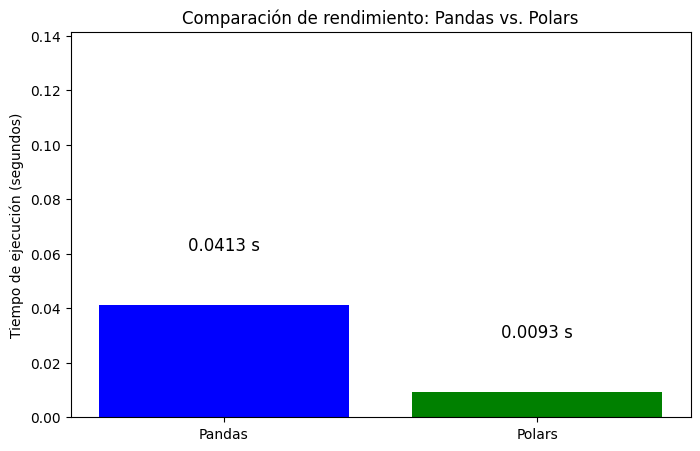

In [ ]:
import matplotlib.pyplot as plt

labels = ['Pandas', 'Polars']
times = [pandas_time, polars_time]  # Usando las variables calculadas

plt.figure(figsize=(8,5))
plt.bar(labels, times, color=['blue', 'green'])

plt.ylabel('Tiempo de ejecución (segundos)')
plt.title('Comparación de rendimiento: Pandas vs. Polars')
plt.ylim(0, max(times) + 0.1)  # Ajuste del eje Y

for i, v in enumerate(times):
    plt.text(i, v + 0.02, f"{v:.4f} s", ha='center', fontsize=12)

plt.show()


<ipython-input-38-830ce1825c8a>:21: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  df_polars_grouped = df_polars_exploded.group_by("genres").agg(pl.count())
<ipython-input-38-830ce1825c8a>:33: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  df_polars_lazy_grouped = df_polars_lazy_exploded.group_by("genres").agg(pl.count())


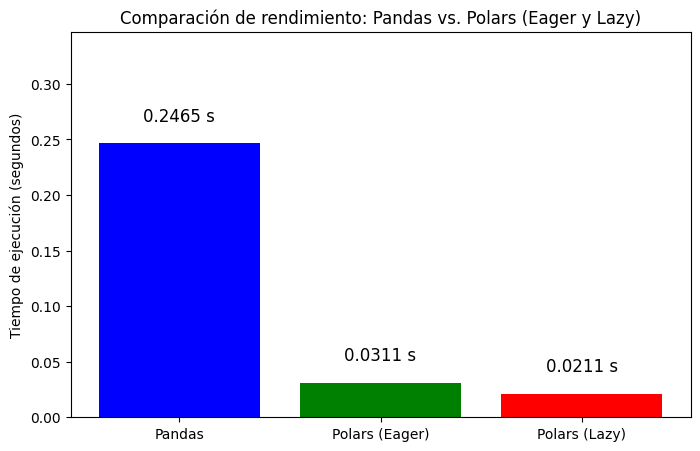

Pandas Time: 0.2465 sec
Polars Eager Time: 0.0311 sec
Polars Lazy Time: 0.0211 sec


In [ ]:
import pandas as pd
import polars as pl
import time
import matplotlib.pyplot as plt

start = time.time()
df_pandas = pd.read_csv("movie.csv")
df_pandas_filtered = df_pandas[df_pandas["genres"].str.contains("Adventure", na=False)]
df_pandas_exploded = df_pandas.assign(genres=df_pandas["genres"].str.split("|")).explode("genres")
df_pandas_grouped = df_pandas_exploded["genres"].value_counts()
df_pandas_titles = df_pandas_exploded.groupby("title")["genres"].count().reset_index().sort_values("genres", ascending=False)
end = time.time()
pandas_time = end - start

start = time.time()
df_polars = pl.read_csv("movie.csv")
df_polars_filtered = df_polars.filter(pl.col("genres").str.contains("Adventure"))
df_polars_exploded = df_polars.with_columns(pl.col("genres").str.split("|")).explode("genres")
df_polars_grouped = df_polars_exploded.group_by("genres").agg(pl.count())
df_polars_titles = df_polars_exploded.group_by("title").agg(pl.count("genres")).sort("genres", descending=True)
end = time.time()
polars_time = end - start

start = time.time()
df_polars_lazy = pl.scan_csv("movie.csv")

df_polars_lazy_filtered = df_polars_lazy.filter(pl.col("genres").str.contains("Adventure"))
df_polars_lazy_exploded = df_polars_lazy.with_columns(pl.col("genres").str.split("|")).explode("genres")
df_polars_lazy_grouped = df_polars_lazy_exploded.group_by("genres").agg(pl.count())
df_polars_lazy_titles = df_polars_lazy_exploded.group_by("title").agg(pl.count("genres")).sort("genres", descending=True)

df_polars_result = df_polars_lazy_titles.collect()
end = time.time()
polars_lazy_time = end - start

labels = ['Pandas', 'Polars (Eager)', 'Polars (Lazy)']
times = [pandas_time, polars_time, polars_lazy_time]  # Usando los valores medidos

plt.figure(figsize=(8,5))
plt.bar(labels, times, color=['blue', 'green', 'red'])

plt.ylabel('Tiempo de ejecución (segundos)')
plt.title('Comparación de rendimiento: Pandas vs. Polars (Eager y Lazy)')
plt.ylim(0, max(times) + 0.1)  # Ajuste del eje Y

for i, v in enumerate(times):
    plt.text(i, v + 0.02, f"{v:.4f} s", ha='center', fontsize=12)

plt.show()

print(f"Pandas Time: {pandas_time:.4f} sec")
print(f"Polars Eager Time: {polars_time:.4f} sec")
print(f"Polars Lazy Time: {polars_lazy_time:.4f} sec")


In [ ]:
import polars as pl

lf = pl.scan_csv("datos.csv")
lf = lf.filter(pl.col("precio") > 50)
lf = lf.select(["nombre", "precio"])
df = lf.collect()


En un DataFrame, las operaciones se harían en este orden:

1. Cargar todos los datos en memoria.

2. Filtrar las filas donde precio > 50.

3. Seleccionar solo nombre y precio.

Pero en LazyFrame, Polars puede reordenar y fusionar operaciones para ser más eficiente:

1. En lugar de leer todo el CSV, solo carga las columnas necesarias (nombre y precio).

2. Luego, aplica el filtro precio > 50.

3. Finalmente, ejecuta y devuelve los resultados.


